In [1]:
!pip install rdkit -q

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem
print("RDKit installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 25.8 MB/s eta 0:00:00
RDKit installed successfully!


In [2]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem
from rdkit.Chem import PandasTools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
print("All imports successful!")

All imports successful!


=== Aspirin ===
Number of atoms: 13
Number of bonds: 13
Number of rings: 1


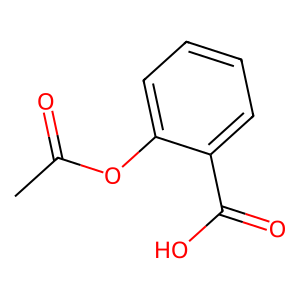

In [3]:
# SMILES (Simplified Molecular Input Line Entry System) is a text
# representation of a molecule's structure

# Load Aspirin
aspirin = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')

print("=== Aspirin ===")
print("Number of atoms:", aspirin.GetNumAtoms())
print("Number of bonds:", aspirin.GetNumBonds())
print("Number of rings:", aspirin.GetRingInfo().NumRings())

# Draw the molecule
img = Draw.MolToImage(aspirin, size=(300, 300))
display(img)

In [4]:
def get_descriptors(smiles, name):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES for {name}")
        return None

    descriptors = {
        "Name": name,
        "SMILES": smiles,
        "Molecular Weight": round(Descriptors.MolWt(mol), 2),
        "LogP": round(Descriptors.MolLogP(mol), 2),
        "H-Bond Donors": Descriptors.NumHDonors(mol),
        "H-Bond Acceptors": Descriptors.NumHAcceptors(mol),
        "Rotatable Bonds": Descriptors.NumRotatableBonds(mol),
        "Aromatic Rings": Descriptors.NumAromaticRings(mol),
        "TPSA": round(Descriptors.TPSA(mol), 2)
    }
    return descriptors

# Test on known drugs
drugs = [
    ("CC(=O)Oc1ccccc1C(=O)O", "Aspirin"),
    ("CC(C)Cc1ccc(cc1)C(C)C(=O)O", "Ibuprofen"),
    ("CN1CCC[C@H]1c2cccnc2", "Nicotine"),
    ("c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34", "Pyrene"),
    ("CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C", "Testosterone")
]

results = []
for smiles, name in drugs:
    desc = get_descriptors(smiles, name)
    if desc:
        results.append(desc)

df = pd.DataFrame(results)
print(df.to_string(index=False))

        Name                              SMILES  Molecular Weight  LogP  H-Bond Donors  H-Bond Acceptors  Rotatable Bonds  Aromatic Rings  TPSA
     Aspirin               CC(=O)Oc1ccccc1C(=O)O            180.16  1.31              1                 3                2               1 63.60
   Ibuprofen          CC(C)Cc1ccc(cc1)C(C)C(=O)O            206.28  3.07              1                 1                4               1 37.30
    Nicotine                CN1CCC[C@H]1c2cccnc2            162.24  1.85              0                 2                1               1 16.13
      Pyrene    c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34            252.32  5.74              0                 0                0               5  0.00
Testosterone CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C            288.43  3.88              1                 2                0               0 37.30


In [5]:
# Lipinski's Rule of Five predicts oral bioavailability of drug candidates
# A drug-like molecule should satisfy ALL of these:
# 1. Molecular Weight <= 500 Da
# 2. LogP <= 5
# 3. H-Bond Donors <= 5
# 4. H-Bond Acceptors <= 10

def lipinski_filter(smiles, name):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"Name": name, "Result": "Invalid SMILES"}

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)

    violations = []
    if mw > 500:
        violations.append(f"MW={mw:.1f} > 500")
    if logp > 5:
        violations.append(f"LogP={logp:.2f} > 5")
    if hbd > 5:
        violations.append(f"HBD={hbd} > 5")
    if hba > 10:
        violations.append(f"HBA={hba} > 10")

    passes = len(violations) == 0
    return {
        "Name": name,
        "MW": round(mw, 1),
        "LogP": round(logp, 2),
        "HBD": hbd,
        "HBA": hba,
        "Passes Lipinski": "✅ Yes" if passes else "❌ No",
        "Violations": ", ".join(violations) if violations else "None"
    }

# Test on a larger set of molecules
molecules = [
    ("CC(=O)Oc1ccccc1C(=O)O", "Aspirin"),
    ("CC(C)Cc1ccc(cc1)C(C)C(=O)O", "Ibuprofen"),
    ("c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34", "Pyrene"),
    ("CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C", "Testosterone"),
    ("CC1=C2C(C(=O)C3(C(CC4C(C3C(C(=O)c5ccccc5)(C4OC(=O)c6ccccc6)O)OC(=O)C)OC(=O)C)(CC2=C)O)=C1", "Paclitaxel"),
    ("CC(=O)Nc1ccc(O)cc1", "Paracetamol"),
    ("OC(=O)c1ccccc1O", "Salicylic Acid"),
    ("CN1C=NC2=C1C(=O)N(C(=O)N2C)C", "Caffeine")
]

lipinski_results = [lipinski_filter(smi, name) for smi, name in molecules]
df_lipinski = pd.DataFrame(lipinski_results)
print(df_lipinski.to_string(index=False))

          Name    MW  LogP  HBD  HBA Passes Lipinski    Violations         Result
       Aspirin 180.2  1.31  1.0  3.0           ✅ Yes          None            NaN
     Ibuprofen 206.3  3.07  1.0  1.0           ✅ Yes          None            NaN
        Pyrene 252.3  5.74  0.0  0.0            ❌ No LogP=5.74 > 5            NaN
  Testosterone 288.4  3.88  1.0  2.0           ✅ Yes          None            NaN
    Paclitaxel   NaN   NaN  NaN  NaN             NaN           NaN Invalid SMILES
   Paracetamol 151.2  1.35  2.0  2.0           ✅ Yes          None            NaN
Salicylic Acid 138.1  1.09  2.0  2.0           ✅ Yes          None            NaN
      Caffeine 194.2 -1.03  0.0  3.0           ✅ Yes          None            NaN


[13:25:09] Explicit valence for atom # 6 C, 5, is greater than permitted


=== Molecules PASSING Lipinski's Rule of Five ===


[13:25:32] Explicit valence for atom # 6 C, 5, is greater than permitted


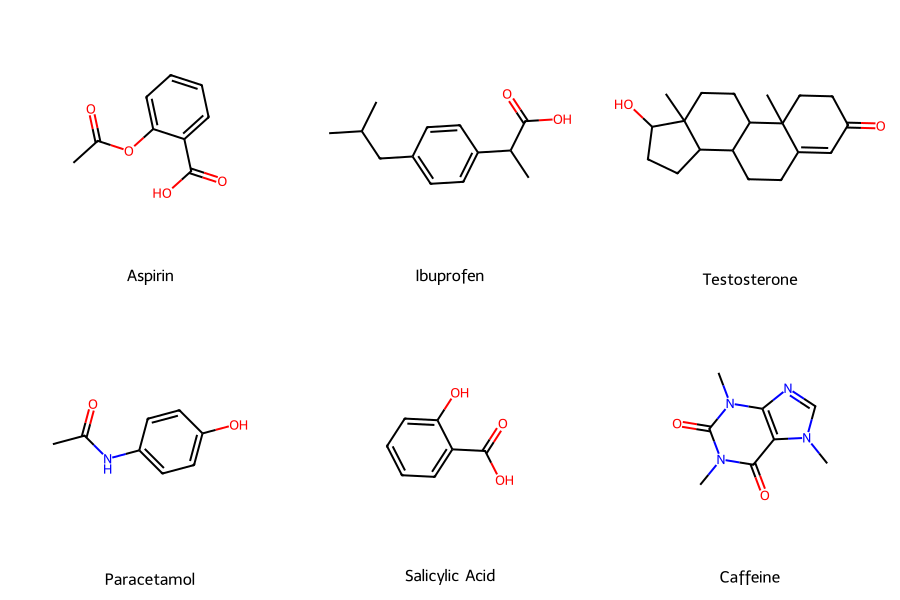


=== Molecules FAILING Lipinski's Rule of Five ===


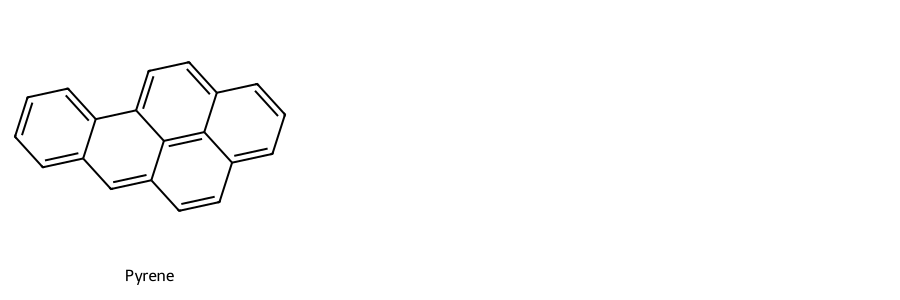

In [6]:
pass_mols = []
pass_names = []
fail_mols = []
fail_names = []

for smi, name in molecules:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        result = lipinski_filter(smi, name)
        if result["Passes Lipinski"] == "✅ Yes":
            pass_mols.append(mol)
            pass_names.append(name)
        else:
            fail_mols.append(mol)
            fail_names.append(name)

print("=== Molecules PASSING Lipinski's Rule of Five ===")
if pass_mols:
    img_pass = Draw.MolsToGridImage(pass_mols, molsPerRow=3,
                                     subImgSize=(300,300),
                                     legends=pass_names)
    display(img_pass)

print("\n=== Molecules FAILING Lipinski's Rule of Five ===")
if fail_mols:
    img_fail = Draw.MolsToGridImage(fail_mols, molsPerRow=3,
                                     subImgSize=(300,300),
                                     legends=fail_names)
    display(img_fail)

In [7]:
# Morgan fingerprints encode the local chemical environment of each atom
# They are the most widely used molecular representation in drug discovery ML

def get_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp)

# Generate fingerprints for all molecules
print("=== Morgan Fingerprints ===")
for smi, name in molecules[:5]:
    fp = get_morgan_fingerprint(smi)
    if fp is not None:
        print(f"\n{name}:")
        print(f"  Fingerprint length: {len(fp)}")
        print(f"  Active bits (non-zero): {np.sum(fp)}")
        print(f"  Sparsity: {(1 - np.sum(fp)/len(fp))*100:.1f}% zeros")
        print(f"  First 30 bits: {fp[:30]}")

=== Morgan Fingerprints ===

Aspirin:
  Fingerprint length: 2048
  Active bits (non-zero): 24
  Sparsity: 98.8% zeros
  First 30 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Ibuprofen:
  Fingerprint length: 2048
  Active bits (non-zero): 25
  Sparsity: 98.8% zeros
  First 30 bits: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Pyrene:
  Fingerprint length: 2048
  Active bits (non-zero): 22
  Sparsity: 98.9% zeros
  First 30 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Testosterone:
  Fingerprint length: 2048
  Active bits (non-zero): 39
  Sparsity: 98.1% zeros
  First 30 bits: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


[13:26:52] DEPRECATION WARNING: please use MorganGenerator
[13:26:52] DEPRECATION WARNING: please use MorganGenerator
[13:26:52] DEPRECATION WARNING: please use MorganGenerator
[13:26:52] DEPRECATION WARNING: please use MorganGenerator
[13:26:52] Explicit valence for atom # 6 C, 5, is greater than permitted


In [10]:
# Tanimoto similarity measures how chemically similar two molecules are
# 0 = completely different, 1 = identical
# Used in virtual screening to find molecules similar to a known drug

from rdkit import DataStructs

def tanimoto_similarity(smiles1, smiles2):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        return None
    fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, 2, 2048)
    fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, 2, 2048)
    return round(DataStructs.TanimotoSimilarity(fp1, fp2), 3)

# Compare Aspirin to all other molecules
aspirin_smi = "CC(=O)Oc1ccccc1C(=O)O"
print("=== Tanimoto Similarity to Aspirin ===")
for smi, name in molecules:
    sim = tanimoto_similarity(aspirin_smi, smi)
    if sim is not None:
        bar = "=" * int(sim * 20)
        print(f"{name:<20} {sim:.3f}  {bar}")
    else:
        print(f"{name:<20} Invalid SMILES")

=== Tanimoto Similarity to Aspirin ===
Aspirin              1.000  ====================
Ibuprofen            0.195  ===
Pyrene               0.122  ==
Testosterone         0.086  =
Paclitaxel           Invalid SMILES
Paracetamol          0.222  ====
Salicylic Acid       0.448  ========
Caffeine             0.089  =


[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] Explicit valence for atom # 6 C, 5, is greater than permitted
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator
[13:27:50] DEPRECATION WARNING: please use MorganGenerator


In [11]:
# Simulate a virtual screening pipeline:
# 1. Take a list of compounds
# 2. Calculate all descriptors
# 3. Apply Lipinski filter
# 4. Calculate similarity to a query drug
# 5. Rank and output top candidates

query_drug = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin as reference

compound_library = [
    ("CC(=O)Oc1ccccc1C(=O)O", "Aspirin"),
    ("CC(C)Cc1ccc(cc1)C(C)C(=O)O", "Ibuprofen"),
    ("CC(=O)Nc1ccc(O)cc1", "Paracetamol"),
    ("OC(=O)c1ccccc1O", "Salicylic Acid"),
    ("CN1C=NC2=C1C(=O)N(C(=O)N2C)C", "Caffeine"),
    ("CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C", "Testosterone"),
    ("c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34", "Pyrene"),
    ("CC1=C2C(C(=O)C3(C(CC4C(C3C(C(=O)c5ccccc5)(C4OC(=O)c6ccccc6)O)OC(=O)C)OC(=O)C)(CC2=C)O)=C1", "Paclitaxel"),
]

print("=== Virtual Screening Pipeline ===")
print(f"Query drug: Aspirin")
print(f"Library size: {len(compound_library)} compounds\n")

screening_results = []
for smi, name in compound_library:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue

    lip = lipinski_filter(smi, name)
    sim = tanimoto_similarity(query_drug, smi)

    screening_results.append({
        "Name": name,
        "MW": lip["MW"],
        "LogP": lip["LogP"],
        "Passes Lipinski": lip["Passes Lipinski"],
        "Similarity to Aspirin": sim
    })

df_screen = pd.DataFrame(screening_results)
df_screen = df_screen.sort_values("Similarity to Aspirin", ascending=False)
print(df_screen.to_string(index=False))

# Filter: only drug-like AND similar compounds
print("\n=== Top Drug-Like Candidates (Lipinski ✅, Similarity > 0.1) ===")
top = df_screen[
    (df_screen["Passes Lipinski"] == "✅ Yes") &
    (df_screen["Similarity to Aspirin"] > 0.1)
]
print(top.to_string(index=False))

=== Virtual Screening Pipeline ===
Query drug: Aspirin
Library size: 8 compounds

          Name    MW  LogP Passes Lipinski  Similarity to Aspirin
       Aspirin 180.2  1.31           ✅ Yes                  1.000
Salicylic Acid 138.1  1.09           ✅ Yes                  0.448
   Paracetamol 151.2  1.35           ✅ Yes                  0.222
     Ibuprofen 206.3  3.07           ✅ Yes                  0.195
        Pyrene 252.3  5.74            ❌ No                  0.122
      Caffeine 194.2 -1.03           ✅ Yes                  0.089
  Testosterone 288.4  3.88           ✅ Yes                  0.086

=== Top Drug-Like Candidates (Lipinski ✅, Similarity > 0.1) ===
          Name    MW  LogP Passes Lipinski  Similarity to Aspirin
       Aspirin 180.2  1.31           ✅ Yes                  1.000
Salicylic Acid 138.1  1.09           ✅ Yes                  0.448
   Paracetamol 151.2  1.35           ✅ Yes                  0.222
     Ibuprofen 206.3  3.07           ✅ Yes                  0

[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] DEPRECATION WARNING: please use MorganGenerator
[13:28:25] Explicit valence for atom # 6 C, 5, is greater than permitted


/tmp/ipykernel_1971/410344307.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_1971/410344307.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_1971/410344307.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(names, rotation=45, ha='right', fontsize=8)


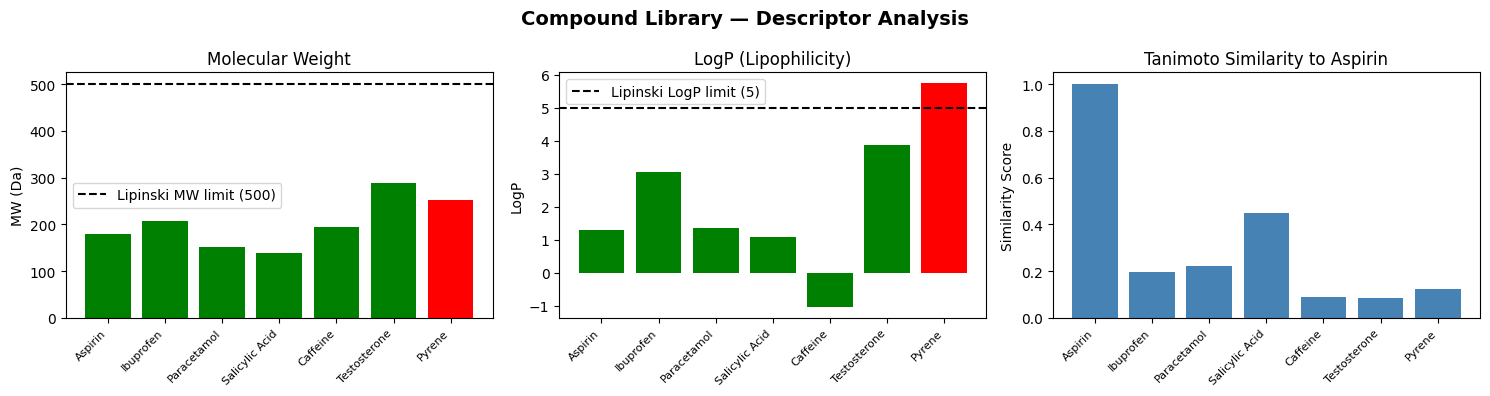

Plot saved!


In [12]:
# Visualise the descriptor space of your compound library
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Compound Library — Descriptor Analysis", fontsize=14, fontweight='bold')

mws = [r["MW"] for r in screening_results]
logps = [r["LogP"] for r in screening_results]
sims = [r["Similarity to Aspirin"] for r in screening_results]
names = [r["Name"] for r in screening_results]
colors = ["green" if r["Passes Lipinski"] == "✅ Yes" else "red" for r in screening_results]

# MW distribution
axes[0].bar(names, mws, color=colors)
axes[0].axhline(y=500, color='black', linestyle='--', label='Lipinski MW limit (500)')
axes[0].set_title("Molecular Weight")
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("MW (Da)")
axes[0].legend()

# LogP distribution
axes[1].bar(names, logps, color=colors)
axes[1].axhline(y=5, color='black', linestyle='--', label='Lipinski LogP limit (5)')
axes[1].set_title("LogP (Lipophilicity)")
axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel("LogP")
axes[1].legend()

# Similarity scores
axes[2].bar(names, sims, color='steelblue')
axes[2].set_title("Tanimoto Similarity to Aspirin")
axes[2].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel("Similarity Score")

plt.tight_layout()
plt.savefig('compound_library_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [13]:
print("=" * 55)
print("  RDKIT MOLECULAR DESCRIPTORS — SUMMARY")
print("=" * 55)
print(f"\n✅ Molecules processed: {len(screening_results)}")
passing = sum(1 for r in screening_results if r["Passes Lipinski"] == "✅ Yes")
print(f"✅ Lipinski-compliant (drug-like): {passing}/{len(screening_results)}")
print(f"✅ Morgan fingerprints generated (2048-bit)")
print(f"✅ Tanimoto similarity calculated for all compounds")
print(f"✅ Virtual screening pipeline complete")
print(f"\nKey concepts covered:")
print(f"  - SMILES molecular representation")
print(f"  - Lipinski Rule of Five filtering")
print(f"  - Morgan circular fingerprints")
print(f"  - Tanimoto chemical similarity")
print(f"  - End-to-end virtual screening pipeline")
print(f"\nRelevance to PhD research:")
print(f"  These are foundational tools used in ML-based")
print(f"  virtual screening and generative drug design.")

  RDKIT MOLECULAR DESCRIPTORS — SUMMARY

✅ Molecules processed: 7
✅ Lipinski-compliant (drug-like): 6/7
✅ Morgan fingerprints generated (2048-bit)
✅ Tanimoto similarity calculated for all compounds
✅ Virtual screening pipeline complete

Key concepts covered:
  - SMILES molecular representation
  - Lipinski Rule of Five filtering
  - Morgan circular fingerprints
  - Tanimoto chemical similarity
  - End-to-end virtual screening pipeline

Relevance to PhD research:
  These are foundational tools used in ML-based
  virtual screening and generative drug design.
